In [1]:
import sys
sys.path.append("../../src/")

from common_imports import *
from kibble_zurek import *

In [152]:
def scaling_collapse(ts,ns,v=1):
    #Set L = 256 which works fine
    L = 512
    #Empty Array
    data= np.empty([len(ns),len(ts)])
    #Loop over taus
    for tau_i in tqdm(range(len(ts))):
        #Define Variables
        tau = ts[tau_i]
        t = sqrt(tau)
        #Define state
        s = state(L,tau,t)
        for n_i in range(len(ns)):
            n = ns[n_i]
            P = abs(P_n(n,s))
            #Append Correlation
            data[n_i,tau_i]= P
    return data

In [167]:
ts = np.logspace(0,3,25)

ns = array([2,3,4,5,6,10,12])


In [168]:
Gn = scaling_collapse(ts,ns)

 96%|█████████▌| 24/25 [00:23<00:01,  1.64s/it]/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/KZ_mech_and_Scaling_dim/../../src/kibble_zurek.py:44: RuntimeWarning: invalid value encountered in scalar multiply
  return prefactor*complex(pcfd(nu,argument))
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/KZ_mech_and_Scaling_dim/../../src/kibble_zurek.py:60: RuntimeWarning: invalid value encountered in multiply
  return prefactor*complex(pcfd(nu,argument))
/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
100%|██████████| 25/25 [00:28<00:00,  1.12s/it]


Text(0.5, 0, '$\\tau$')

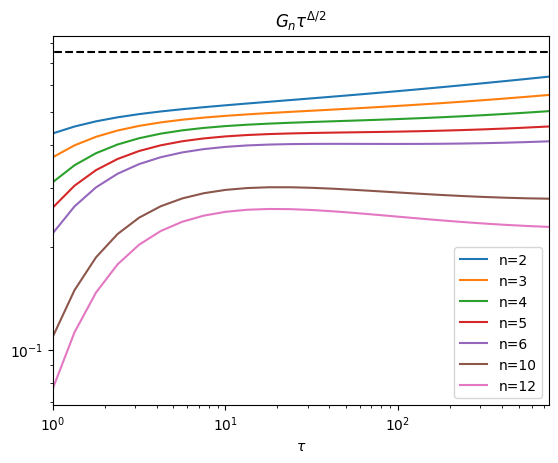

In [180]:
for i,n in enumerate(ns):
    data = Gn[i]
    plot((ts),data*ts**(1/16),label=f"n={n}")


xlim(1,ts[-2])
plt.hlines(3/4,0,ts[-1],ls="--",color="black")
loglog()
legend()
title(r"$G_n \tau ^{\Delta/2}$")
xlabel(r"$\tau$")

In [48]:
Gn[0]

array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
       0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5])